# PASTA: what an arriving customer sees is *not* always the average

Ask a natural question: when a request arrives, how many others does it find already in the system?
The obvious guess is "the average number in the system." That guess is **only correct for Poisson
arrivals** — the property called **PASTA: Poisson Arrivals See Time Averages**.

With any other arrival pattern the arriving customer sees something *different* from the time
average, and the difference can be huge. This matters whenever you (a) measure a system by sampling
it at arrival/request instants, or (b) trust a formula that secretly assumes Poisson input.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.grid": True, "font.size": 11})

def simulate(arrival_kind, lam=0.6, mu=1.0, horizon=500_000, seed=2, nmax=40):
    # single server; measure BOTH the time-average distribution of #-in-system and
    # the distribution seen by arriving customers.
    rng = np.random.default_rng(seed)
    def next_interarrival():
        return rng.exponential(1 / lam) if arrival_kind == "Poisson" else 1.0 / lam  # else deterministic
    t, n, last = 0.0, 0, 0.0
    time_in_state = np.zeros(nmax)
    seen_by_arrival = np.zeros(nmax)
    next_a = next_interarrival()
    next_d = np.inf
    while t < horizon:
        if next_a <= next_d:                      # an arrival
            time_in_state[min(n, nmax - 1)] += next_a - last
            t = last = next_a
            seen_by_arrival[min(n, nmax - 1)] += 1   # this arrival sees n
            n += 1
            if n == 1:
                next_d = t + rng.exponential(1 / mu)
            next_a = t + next_interarrival()
        else:                                     # a departure
            time_in_state[min(n, nmax - 1)] += next_d - last
            t = last = next_d
            n -= 1
            next_d = t + rng.exponential(1 / mu) if n > 0 else np.inf
    return time_in_state / time_in_state.sum(), seen_by_arrival / seen_by_arrival.sum()


## Poisson vs deterministic arrivals into the same server

Both systems have the same average arrival rate (λ=0.6) and the same server (μ=1). Only the *pattern*
of arrivals differs: memoryless (Poisson) vs perfectly regular (deterministic, one every `1/λ`).

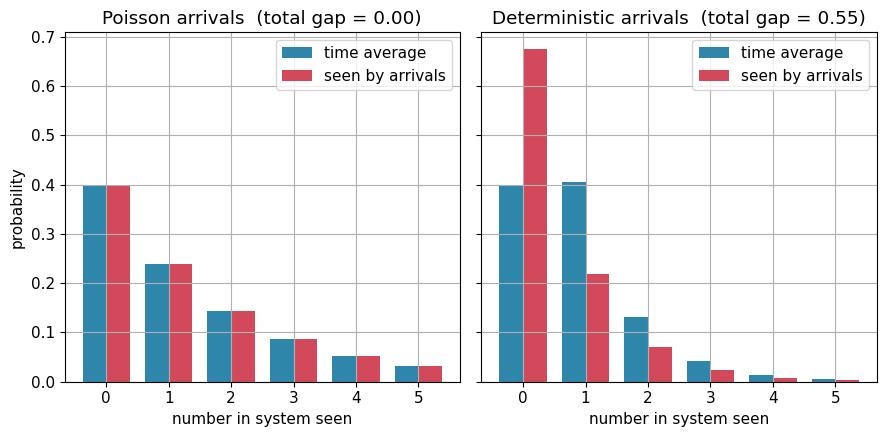

Poisson       : P(find system empty) -- time avg = 0.400, seen by arrivals = 0.400
Deterministic : P(find system empty) -- time avg = 0.400, seen by arrivals = 0.675


In [2]:
fig, axes = plt.subplots(1, 2, sharey=True)
for ax, kind in zip(axes, ["Poisson", "Deterministic"]):
    p_time, p_arr = simulate(kind)
    ks = np.arange(6)
    w = 0.38
    ax.bar(ks - w/2, p_time[:6], w, label="time average", color="#2e86ab")
    ax.bar(ks + w/2, p_arr[:6], w, label="seen by arrivals", color="#d1495b")
    diff = np.abs(p_time[:12] - p_arr[:12]).sum()
    ax.set_title(f"{kind} arrivals  (total gap = {diff:.2f})")
    ax.set_xlabel("number in system seen")
    ax.legend()
axes[0].set_ylabel("probability")
plt.tight_layout()
plt.show()

for kind in ["Poisson", "Deterministic"]:
    pt, pa = simulate(kind)
    print(f"{kind:14}: P(find system empty) -- time avg = {pt[0]:.3f}, seen by arrivals = {pa[0]:.3f}")


**The insight.** For **Poisson** arrivals the two distributions coincide — arrivals are unbiased
observers, because the memoryless gap between arrivals is statistically independent of the system
state (PASTA). For **deterministic** arrivals they diverge sharply: a regularly-spaced arrival finds
the system **empty ~68% of the time** versus a ~40% time-average — evenly spaced arrivals *avoid*
the congestion they would otherwise sample, so they see a much emptier system than a random observer
would.

## Why this bites engineers

- **Biased monitoring.** If you estimate queue length by logging it only when a request arrives, and
  your traffic isn't Poisson (it rarely is — think batched cron jobs, polling, rate limiters), your
  estimate is biased. Sample on a **clock** (time average), or know your arrival process.
- **Formula assumptions.** A huge fraction of closed-form queueing results assume Poisson input
  precisely so that "arriving customer sees the stationary state" holds. Feed them bursty or
  regular traffic and the mapping breaks.
- The library's Markovian calculators assume Poisson (PASTA); for correlated/bursty input use the
  **MAP/PH** models (see [map_ph_correlation.ipynb](map_ph_correlation.ipynb)).

## Takeaways

- **PASTA**: only *Poisson* arrivals see the time-average system state. It's what makes M/M/·
  formulas line up with "what a customer experiences."
- Non-Poisson arrivals sample the system with a bias — regular arrivals see it emptier, bursty
  arrivals see it fuller.
- Mind how you *sample* when you measure, and mind the input assumptions of any formula you trust.